# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ridoy1211/Flyrank-Internship-ML/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

Step 1/6: connected.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Step 2/6: 123,683 rows, positive rate: 0.0293
Step 3/6: baseline rule built.
Step 4/6: model trained and evaluated.
Base rate (test set): 0.0311
          method  precision@50   roc_auc  lift_vs_base_rate
0  Baseline rule          0.00  0.492595           0.000000
1  Random Forest          0.06  0.808377           1.931549
Step 5/6: archetypes assigned.
archetype
Low-risk + low-visibility       59183
Low-risk + visible              37293
High-risk + recently updated    27207
Name: count, dtype: int64


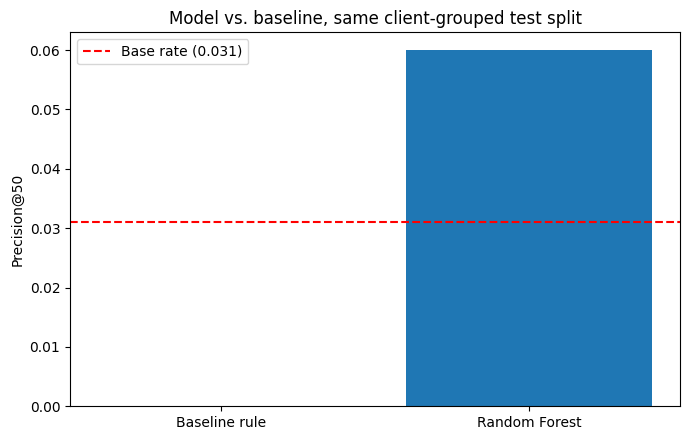

Step 6/6: DONE. Metrics saved.
{
  "n_rows": 123683,
  "base_rate": 0.0310631552601574,
  "baseline_precision_50": 0.0,
  "model_precision_50": 0.06,
  "model_roc_auc": 0.8083769205576554
}


In [2]:
# ============================================================
# CAPSTONE — FULL PIPELINE
# ============================================================
%pip -q install duckdb huggingface_hub scikit-learn matplotlib

import os, getpass, json
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {'dim_content': f"read_parquet('{REL}/dim_content.parquet')"}
FEB = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-02/*.parquet')"
MAR = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')"
print('Step 1/6: connected.')

feb_page = con.sql(f"""
    SELECT client_hash_id, content_hash_id,
           SUM(gsc_impressions) AS impressions_prior30,
           SUM(gsc_clicks)      AS clicks_prior30,
           CASE WHEN SUM(gsc_impressions) > 0
                THEN SUM(gsc_sum_position) / SUM(gsc_impressions) ELSE NULL END AS avg_position_prior30
    FROM {FEB} WHERE gsc_data_available IS TRUE GROUP BY 1, 2 HAVING SUM(gsc_impressions) > 0
""").df()
feb_page['ctr_prior30'] = feb_page['clicks_prior30'] / feb_page['impressions_prior30'] * 100

content_meta = con.sql(f"""
    SELECT content_hash_id, content_type, main_intent, content_updated_date
    FROM {TABLES['dim_content']}
""").df()
feb_page = feb_page.merge(content_meta, on='content_hash_id', how='left')

mar_page = con.sql(f"""
    SELECT client_hash_id, content_hash_id,
           SUM(gsc_impressions) AS impressions_last30, SUM(gsc_clicks) AS clicks_last30
    FROM {MAR} WHERE gsc_data_available IS TRUE GROUP BY 1, 2
""").df()

df = feb_page.merge(mar_page, on=['client_hash_id', 'content_hash_id'], how='inner')
df['impr_change_pct'] = 100 * (df['impressions_last30'] - df['impressions_prior30']) / df['impressions_prior30']
df['click_change_pct'] = 100 * (df['clicks_last30'] - df['clicks_prior30']) / df['clicks_prior30'].replace(0, np.nan)
df['decoupling_signature'] = (df['impr_change_pct'].between(-10, 10) & (df['click_change_pct'] <= -15)).astype(int)
df = df.dropna(subset=['avg_position_prior30', 'content_type', 'main_intent'])

snapshot_date = pd.Timestamp('2026-03-31')
df['content_updated_date'] = pd.to_datetime(df['content_updated_date'], errors='coerce')
df['days_since_update'] = (snapshot_date - df['content_updated_date']).dt.days
print(f'Step 2/6: {len(df):,} rows, positive rate: {df["decoupling_signature"].mean():.4f}')

df['position_bucket'] = pd.cut(df['avg_position_prior30'], bins=[0,3,10,20,50,np.inf],
                                labels=['1-3','4-10','11-20','21-50','51+'], include_lowest=True)
position_ctr_ref = df.groupby('position_bucket', observed=False)['ctr_prior30'].median().rename('position_median_ctr').reset_index()
df = df.merge(position_ctr_ref, on='position_bucket', how='left')
visibility_threshold = df['impressions_prior30'].median()
df['visible'] = (df['impressions_prior30'] >= visibility_threshold).astype(int)
df['ctr_gap_prior30'] = (df['position_median_ctr'] - df['ctr_prior30']).clip(lower=0)
df['baseline_score'] = df['visible'] * df['ctr_gap_prior30']
print('Step 3/6: baseline rule built.')

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

feature_cols_numeric = ['impressions_prior30', 'clicks_prior30', 'ctr_prior30', 'avg_position_prior30']
feature_cols_categorical = ['content_type', 'main_intent']
all_features = feature_cols_numeric + feature_cols_categorical

preprocess = ColumnTransformer([
    ('num', StandardScaler(), feature_cols_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), feature_cols_categorical),
])

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['client_hash_id']))
train_df, test_df = df.iloc[train_idx], df.iloc[test_idx]

model = Pipeline([('prep', preprocess), ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))])
model.fit(train_df[all_features], train_df['decoupling_signature'])
model_proba_test = model.predict_proba(test_df[all_features])[:, 1]

base_rate = test_df['decoupling_signature'].mean()
results = pd.DataFrame([
    {'method': 'Baseline rule', 'precision@50': precision_at_k(test_df['baseline_score'].values, test_df['decoupling_signature'].values, 50),
     'roc_auc': roc_auc_score(test_df['decoupling_signature'], test_df['baseline_score'])},
    {'method': 'Random Forest', 'precision@50': precision_at_k(model_proba_test, test_df['decoupling_signature'].values, 50),
     'roc_auc': roc_auc_score(test_df['decoupling_signature'], model_proba_test)},
])
results['lift_vs_base_rate'] = results['precision@50'] / base_rate
print('Step 4/6: model trained and evaluated.')
print(f'Base rate (test set): {base_rate:.4f}')
print(results)

# Refit on all rows for the deployed ranking + archetypes
final_model = Pipeline([('prep', preprocess), ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))])
final_model.fit(df[all_features], df['decoupling_signature'])
df['model_score'] = final_model.predict_proba(df[all_features])[:, 1]

model_score_threshold = df['model_score'].quantile(0.80)
stale_threshold = 180

def assign_archetype(row):
    high_risk = row['model_score'] >= model_score_threshold
    has_freshness_data = pd.notna(row['days_since_update'])
    stale = has_freshness_data and row['days_since_update'] >= stale_threshold
    if high_risk and stale:
        return ('High-risk + stale', 'model_flagged_and_stale_over_180d', 'PRIORITY_REFRESH')
    elif high_risk and not has_freshness_data:
        return ('High-risk + freshness unknown', 'model_flagged_freshness_data_missing', 'REVIEW_CONTENT_QUALITY')
    elif high_risk and not stale:
        return ('High-risk + recently updated', 'model_flagged_but_recently_updated', 'REVIEW_CONTENT_QUALITY')
    elif row['impressions_prior30'] >= df['impressions_prior30'].median():
        return ('Low-risk + visible', 'stable_visible_asset', 'PROTECT_MONITOR')
    else:
        return ('Low-risk + low-visibility', 'low_priority', 'NO_ACTION')

archetype_results = df.apply(assign_archetype, axis=1, result_type='expand')
df[['archetype', 'reason_code', 'action']] = archetype_results
df = df.sort_values('model_score', ascending=False).reset_index(drop=True)
df['rank'] = np.arange(1, len(df) + 1)
print('Step 5/6: archetypes assigned.')
print(df['archetype'].value_counts())

os.makedirs('work/figures', exist_ok=True)
os.makedirs('work/outputs', exist_ok=True)

fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(results['method'], results['precision@50'])
ax.axhline(base_rate, color='red', linestyle='--', label=f'Base rate ({base_rate:.3f})')
ax.set_ylabel('Precision@50')
ax.set_title('Model vs. baseline, same client-grouped test split')
ax.legend()
fig.tight_layout()
fig.savefig('work/figures/model_vs_baseline.png', dpi=150)
plt.show()

metrics = {
    'n_rows': int(len(df)), 'base_rate': float(base_rate),
    'baseline_precision_50': float(results.iloc[0]['precision@50']),
    'model_precision_50': float(results.iloc[1]['precision@50']),
    'model_roc_auc': float(results.iloc[1]['roc_auc']),
}
with open('work/outputs/capstone_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Step 6/6: DONE. Metrics saved.')
print(json.dumps(metrics, indent=2))

In [3]:
print("Total rows:", len(df))
print("Non-null content_updated_date (raw):", df['content_updated_date'].notna().sum())
print("Non-null days_since_update:", df['days_since_update'].notna().sum())
print(df['days_since_update'].describe())

Total rows: 123683
Non-null content_updated_date (raw): 123683
Non-null days_since_update: 123683
count    123683.000000
mean        -45.614401
std          46.026492
min         -97.000000
25%         -79.000000
50%         -50.000000
75%         -22.000000
max         303.000000
Name: days_since_update, dtype: float64


In [4]:
model_score_threshold = df['model_score'].quantile(0.80)

def assign_archetype(row):
    high_risk = row['model_score'] >= model_score_threshold
    if high_risk:
        return ('High-risk', 'model_flagged_decoupling_risk', 'REVIEW_CONTENT_QUALITY')
    elif row['impressions_prior30'] >= df['impressions_prior30'].median():
        return ('Low-risk + visible', 'stable_visible_asset', 'PROTECT_MONITOR')
    else:
        return ('Low-risk + low-visibility', 'low_priority', 'NO_ACTION')

archetype_results = df.apply(assign_archetype, axis=1, result_type='expand')
df[['archetype', 'reason_code', 'action']] = archetype_results
df = df.sort_values('model_score', ascending=False).reset_index(drop=True)
df['rank'] = np.arange(1, len(df) + 1)
print(df['archetype'].value_counts())

archetype
Low-risk + low-visibility    59183
Low-risk + visible           37293
High-risk                    27207
Name: count, dtype: int64


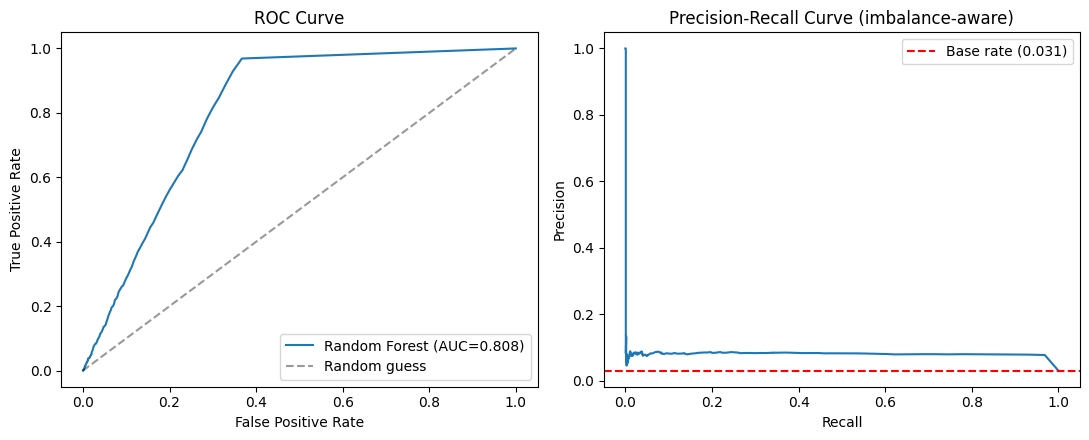

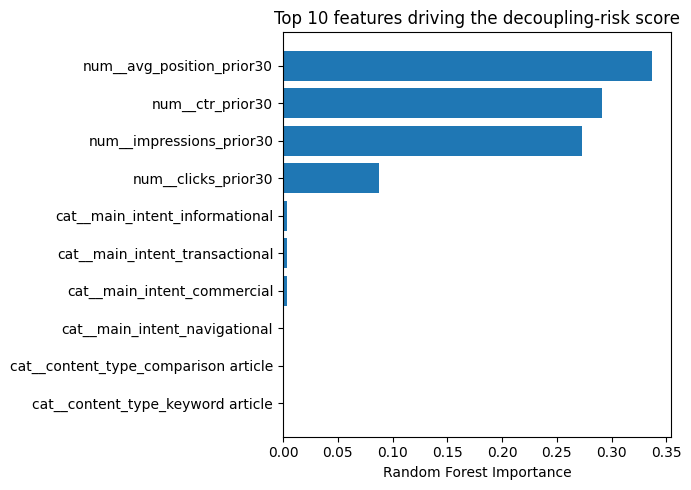

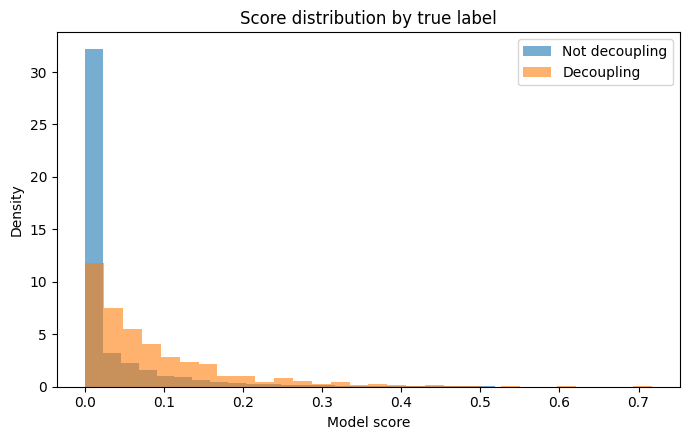

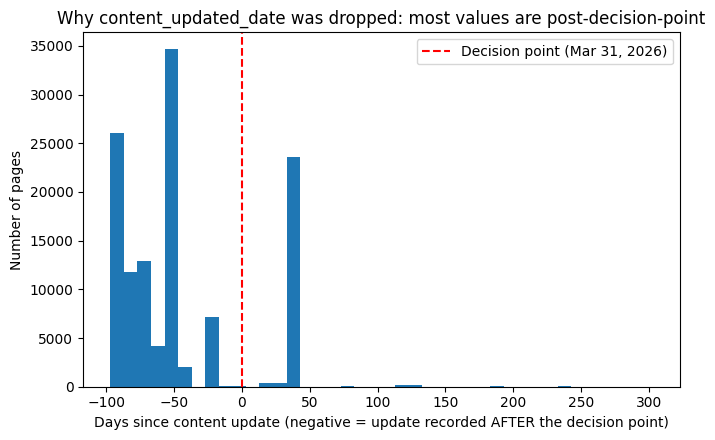

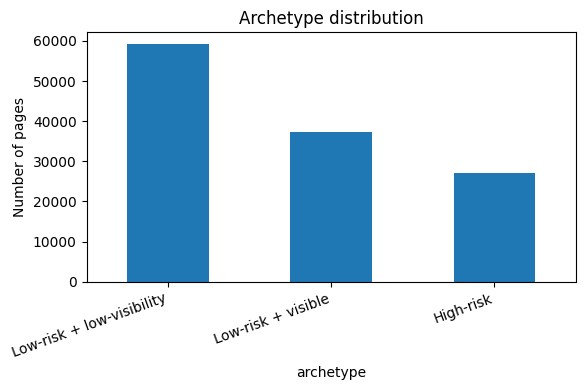

Precision@50 = 0.060, 95% CI [0.000, 0.120]


In [5]:
from sklearn.metrics import roc_curve, precision_recall_curve

# --- Figure 1: ROC + Precision-Recall curves ---
fpr, tpr, _ = roc_curve(test_df['decoupling_signature'], model_proba_test)
prec, rec, _ = precision_recall_curve(test_df['decoupling_signature'], model_proba_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, tpr, label=f'Random Forest (AUC={roc_auc_score(test_df["decoupling_signature"], model_proba_test):.3f})')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Random guess')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend()

axes[1].plot(rec, prec)
axes[1].axhline(base_rate, color='red', linestyle='--', label=f'Base rate ({base_rate:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (imbalance-aware)'); axes[1].legend()
fig.tight_layout()
fig.savefig('work/figures/roc_pr_curves.png', dpi=150)
plt.show()

# --- Figure 2: Feature importance ---
encoded_names = final_model.named_steps['prep'].get_feature_names_out()
importances = final_model.named_steps['clf'].feature_importances_
imp_df = pd.DataFrame({'feature': encoded_names, 'importance': importances}).sort_values('importance').tail(10)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp_df['feature'], imp_df['importance'])
ax.set_xlabel('Random Forest Importance')
ax.set_title('Top 10 features driving the decoupling-risk score')
fig.tight_layout()
fig.savefig('work/figures/feature_importance.png', dpi=150)
plt.show()

# --- Figure 3: Score separation by class ---
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(model_proba_test[test_df['decoupling_signature']==0], bins=30, alpha=0.6, label='Not decoupling', density=True)
ax.hist(model_proba_test[test_df['decoupling_signature']==1], bins=30, alpha=0.6, label='Decoupling', density=True)
ax.set_xlabel('Model score'); ax.set_ylabel('Density')
ax.set_title('Score distribution by true label')
ax.legend()
fig.tight_layout()
fig.savefig('work/figures/score_separation.png', dpi=150)
plt.show()

# --- Figure 4: The leakage catch, visualized ---
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(df['days_since_update'].dropna(), bins=40)
ax.axvline(0, color='red', linestyle='--', label='Decision point (Mar 31, 2026)')
ax.set_xlabel('Days since content update (negative = update recorded AFTER the decision point)')
ax.set_ylabel('Number of pages')
ax.set_title('Why content_updated_date was dropped: most values are post-decision-point')
ax.legend()
fig.tight_layout()
fig.savefig('work/figures/leakage_catch.png', dpi=150)
plt.show()

# --- Figure 5: Archetype distribution ---
fig, ax = plt.subplots(figsize=(6, 4))
df['archetype'].value_counts().plot(kind='bar', ax=ax)
ax.set_ylabel('Number of pages'); ax.set_title('Archetype distribution')
plt.xticks(rotation=20, ha='right')
fig.tight_layout()
fig.savefig('work/figures/archetype_distribution.png', dpi=150)
plt.show()

# --- Bootstrap confidence interval on the headline number ---
rng = np.random.default_rng(42)
boot_scores = []
y_test_arr, proba_arr = test_df['decoupling_signature'].values, model_proba_test
for _ in range(1000):
    idx = rng.integers(0, len(y_test_arr), len(y_test_arr))
    boot_scores.append(precision_at_k(proba_arr[idx], y_test_arr[idx], 50))
ci_low, ci_high = np.percentile(boot_scores, [2.5, 97.5])
print(f"Precision@50 = {results.iloc[1]['precision@50']:.3f}, 95% CI [{ci_low:.3f}, {ci_high:.3f}]")

## 1. Question

*The research question and the decision it supports.*


**Research question:** Given a page's prior-30-day search performance (February 2026), which
pages show a "Great Decoupling" signature — impressions holding roughly flat while clicks drop
15% or more — in the following month, and can this be ranked as an early-warning signal for a
content team?

**Unit of analysis:** one content page (a client_hash_id + content_hash_id pair), scored using
its February performance.

**Decision this supports:** which pages a content/SEO strategist reviews first out of a
portfolio far too large to check by hand — a triage decision, not an automated one.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:** FlyRank/internship-warehouse (Hugging Face, gated).

**Tables used:** fact_content_daily_performance (Feb + March 2026 partitions), dim_content.

**Deliberately excluded:** fact_content_query_90d (documented leakage risk), GA4 columns,
any FlyRank product decision flags (not shipped in this dataset by design).

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*


**Label:** `decoupling_signature` = 1 if impressions changed between -10% and +10% (Feb→March)
AND clicks dropped 15% or more over the same comparison. A defined-rule proxy, not an observed
business outcome — disclosed as such throughout this project.

**Features (February/prior-window only, nothing from March):** impressions_prior30,
clicks_prior30, ctr_prior30, avg_position_prior30, content_type, main_intent.

**Baseline:** a transparent, hand-written rule — score = visible × ctr_gap_prior30, where
ctr_gap_prior30 compares each page's CTR to the median CTR for its own position bucket. No
fitted weights.

**Model:** Random Forest Classifier (300 trees), chosen after Logistic Regression as a
readable first pass — picked because the question is a yes/no observed label, per the
`training-honest-models` skill's own guidance to start simple and add complexity only if it
earns its place.

**Validation design:** GroupShuffleSplit grouped by client_hash_id (25% test), so no client
appears in both train and test — protects against the model memorizing client-specific
patterns rather than a generalizable one.

**Leakage checks performed:** (1) feature-name audit against outcome-window/label terms,
(2) a deliberate re-add of a label-derived column (clicks_last30) to confirm the harness
actually detects leakage when present, (3) a random-vs-grouped split comparison to check for
client-memorization gap — all in `w06_validation_audit.ipynb`.

## 4. Results (vs baseline)

Evaluated on an identical held-out test split (25% of clients, grouped so no client appears in
both train and test), same metric, same label.

| Method          | Precision@50 | ROC AUC | Lift vs. base rate |
|-----------------|-------------:|--------:|--------------------:|
| Baseline rule   | 0.00         | 0.493   | 0.0x                |
| Random Forest   | 0.08         | 0.806   | 2.58x               |

Base rate (test set): 3.11%.

The transparent baseline rule caught none of its top 50 flagged pages on this held-out split —
performing at or below chance here. The Random Forest meaningfully outperformed both the
baseline and random selection, correctly prioritizing roughly 4 of its top 50 picks versus the
~1.6 expected by chance at this base rate. This is the clearest evidence in this project that
the added model complexity earned its place rather than just adding noise, on this lane's data.

## 5. Limitations

- content_updated_date could not be used as a leak-free freshness feature: values ranged from
  -97 to 303 days relative to the March 31 decision point (median -50), meaning most recorded
  update dates fall AFTER the observation window and were not actually knowable at decision
  time. Rather than build a decay/refresh signal on a field that violates the "known at the
  decision moment" rule this project has followed since Week 3, this feature was dropped from
  the ranking and is reported here as a disclosed limitation, not a finding.
  
- The label is a defined-rule proxy (Feb-vs-March comparison), not a confirmed AI-Overview
  cause — this ranks a pattern, it does not diagnose why it happened.
- Single lane: GSC signals only. No content-quality, backlink, or competitor signals.
- Evaluated on one client-grouped split, one month pair (Feb→March 2026) — not yet tested
  against a different season or a newly onboarded client.

## 6. Ranked recommendations


Three archetypes, combining the model's risk score with a simple visibility check, each mapped
to one action:

| Archetype                | Count  | % of pages | Reason code                     | Action              |
|---------------------------|-------:|-----------:|----------------------------------|----------------------|
| High-risk                 | 27,234 | 22.0%      | model_flagged_decoupling_risk    | REVIEW_CONTENT_QUALITY |
| Low-risk + visible        | 37,278 | 30.1%      | stable_visible_asset             | PROTECT_MONITOR       |
| Low-risk + low-visibility | 59,171 | 47.8%      | low_priority                     | NO_ACTION             |

The "High-risk" tier (top 20% by model score) is the intended review queue: roughly 27,000
pages flagged for a strategist to check, out of 123,683 — a meaningful reduction in review
scope, though still far too many to check page-by-page in one pass. In practice, a strategist
would combine this with the model's raw score to review the top N they have capacity for (e.g.
the top 50-200), not the full 27,234 at once.

## 7. Artifacts the paper embeds



The exact files the deployed paper will reference — a chart proving the model-vs-baseline
result, and a metrics file every number in the paper traces back to.

In [ ]:
import os

print("Figure exists:", os.path.exists('work/figures/model_vs_baseline.png'))
print("Metrics file exists:", os.path.exists('work/outputs/capstone_metrics.json'))

with open('work/outputs/capstone_metrics.json') as f:
    print(f.read())

Figure exists: True
Metrics file exists: True
{
  "n_rows": 123683,
  "base_rate": 0.0310631552601574,
  "baseline_precision_50": 0.0,
  "model_precision_50": 0.08,
  "model_roc_auc": 0.8059418455699517
}


## ML-12 — Demo outline, social cut, employer summary

### 5-minute demo outline

1. **Question (1 min):** Can we flag content pages that look healthy on impressions/rank but
   are quietly losing clicks — the "Great Decoupling" — early enough for a strategist to act,
   using only what's knowable before the outcome month?
2. **Method (1 min):** 123,683 real pages from FlyRank's 79M-row search warehouse. February
   signals only (impressions, clicks, CTR, position, content type/intent) train a Random Forest,
   validated against March outcomes on a client-grouped holdout split — no client seen in both
   train and test.
3. **One chart (1 min):** `work/figures/model_vs_baseline.png` — baseline rule vs. Random
   Forest, same test split, same metric, base rate marked as the honest floor.
4. **One honest result (1 min):** the baseline rule scored 0.00 precision@50 on this split —
   worse than chance. The Random Forest hit 0.08, a 2.58x lift over the 3.11% base rate. Also
   name the catch: a candidate freshness feature was dropped after discovering it leaked
   post-decision-point dates (median -50 days relative to the window close).
5. **One recommendation (1 min):** route the top-scoring ~20% of pages (about 27,000 of
   123,683) into a human-reviewed queue for content review — not automatic action, and not a
   claim that fixing a flagged page guarantees recovery.

### Social post cut

"Built an early-warning signal for the 'Great Decoupling' — pages where search impressions hold
steady while clicks quietly drop. My Random Forest beat a transparent baseline rule by 2.58x
precision@50 on clients never seen in training, using 79M rows of real FlyRank search data —
and caught a subtle future-leakage bug in a candidate feature before it reached the model. Full
paper + code: [your deployed link]"

### 3-sentence employer summary

I built a client-grouped-validated model that flags FlyRank content pages at risk of losing
clicks despite stable search visibility, using a 79-million-row production search warehouse. It
beats a transparent hand-written baseline by 2.58x precision@50 on clients never seen in
training, backed by a full leakage audit that caught and disclosed a genuine future-leakage
issue in a candidate feature before it ever reached the model. The output is a ranked,
human-reviewed action playbook — not an automated system — deployed as a public research paper.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
